<a href="https://colab.research.google.com/github/Pramit44/Hospital-los-predictor-Length-of-Stay-/blob/main/Hospital_Length_of__Stay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [167]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [168]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib as jb
import json as js

In [169]:
path=("/content/drive/MyDrive/LengthOfStay.csv")
df=pd.read_csv(path)
df.head()

,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,...,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,...,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,...,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,...,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,...,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4




                              
##                            **EDA**

In [170]:
df.isnull().sum()

,0
eid,0
vdate,0
rcount,0
gender,0
dialysisrenalendstage,0
asthma,0
irondef,0
pneum,0
substancedependence,0
psychologicaldisordermajor,0


In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   vdate                       100000 non-null  object 
 2   rcount                      100000 non-null  object 
 3   gender                      100000 non-null  object 
 4   dialysisrenalendstage       100000 non-null  int64  
 5   asthma                      100000 non-null  int64  
 6   irondef                     100000 non-null  int64  
 7   pneum                       100000 non-null  int64  
 8   substancedependence         100000 non-null  int64  
 9   psychologicaldisordermajor  100000 non-null  int64  
 10  depress                     100000 non-null  int64  
 11  psychother                  100000 non-null  int64  
 12  fibrosisandother            100000 non-null  int64  
 13  malnutrition   

In [172]:
df["rcount"].value_counts()

,count
rcount,
0,55031
1,15007
2,9987
3,8047
4,6941
5+,4987


array([[<Axes: title={'center': 'eid'}>,
        <Axes: title={'center': 'dialysisrenalendstage'}>,
        <Axes: title={'center': 'asthma'}>,
        <Axes: title={'center': 'irondef'}>,
        <Axes: title={'center': 'pneum'}>],
       [<Axes: title={'center': 'substancedependence'}>,
        <Axes: title={'center': 'psychologicaldisordermajor'}>,
        <Axes: title={'center': 'depress'}>,
        <Axes: title={'center': 'psychother'}>,
        <Axes: title={'center': 'fibrosisandother'}>],
       [<Axes: title={'center': 'malnutrition'}>,
        <Axes: title={'center': 'hemo'}>,
        <Axes: title={'center': 'hematocrit'}>,
        <Axes: title={'center': 'neutrophils'}>,
        <Axes: title={'center': 'sodium'}>],
       [<Axes: title={'center': 'glucose'}>,
        <Axes: title={'center': 'bloodureanitro'}>,
        <Axes: title={'center': 'creatinine'}>,
        <Axes: title={'center': 'bmi'}>,
        <Axes: title={'center': 'pulse'}>],
       [<Axes: title={'center': 'r

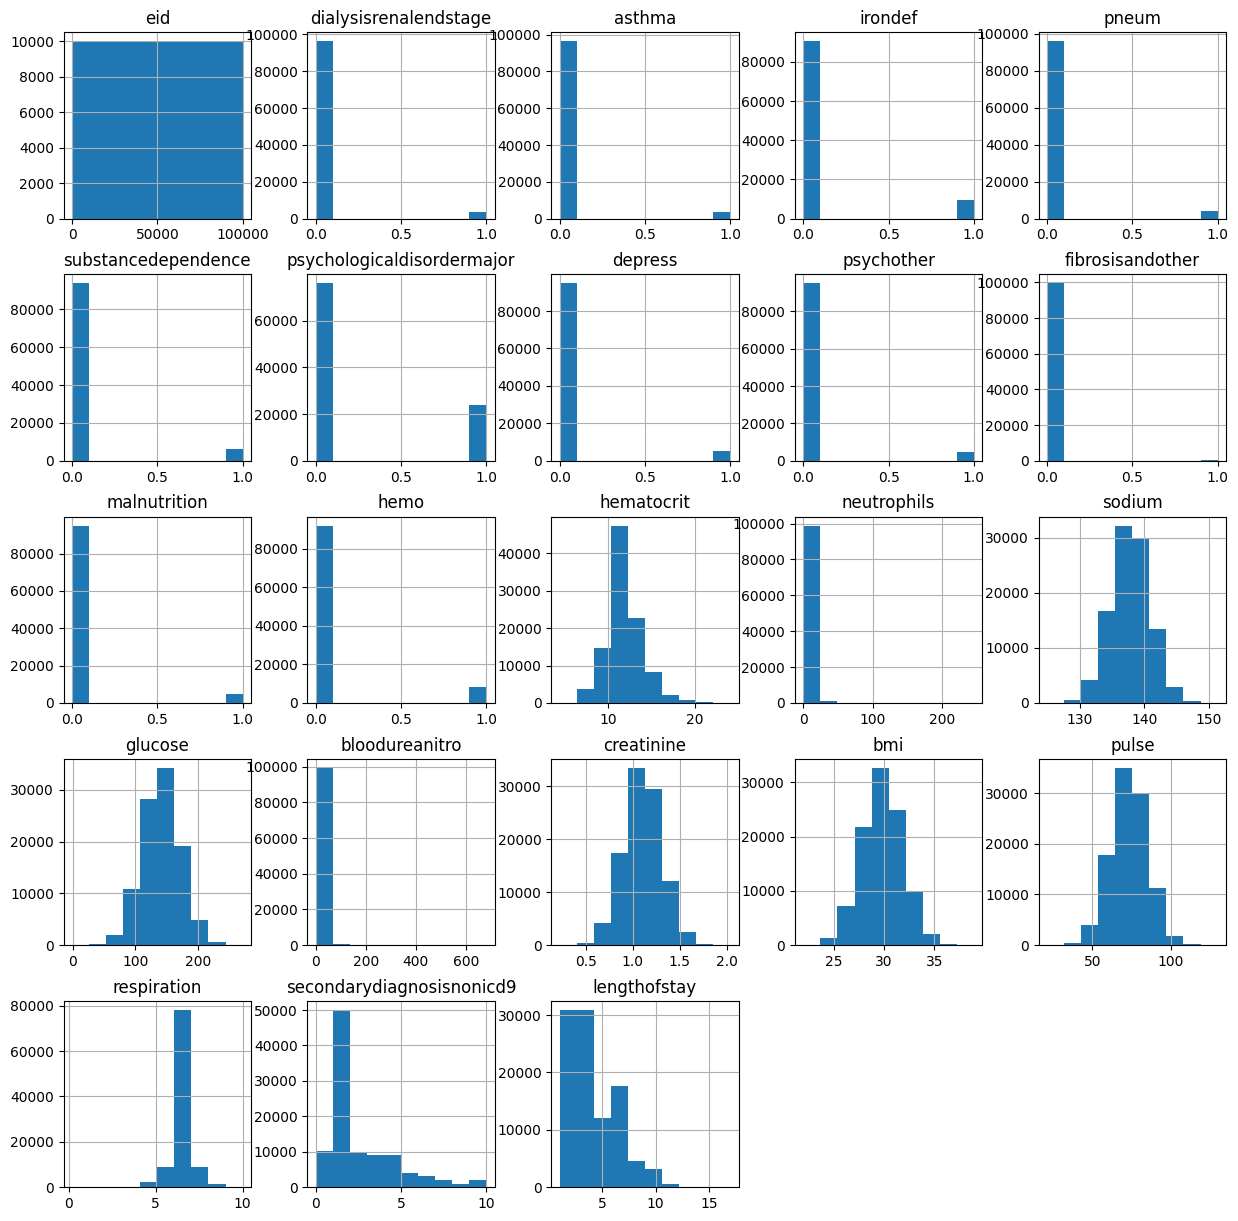

In [173]:
df.hist(figsize=(15,15))


<Axes: xlabel='hemo', ylabel='lengthofstay'>

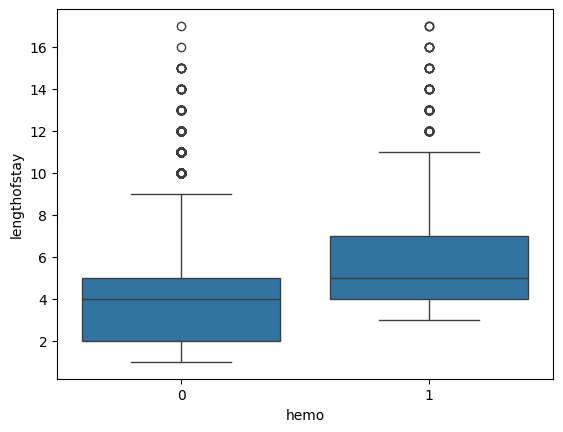

In [174]:
sns.boxplot(data=df,x="hemo",y="lengthofstay")

<Axes: xlabel='respiration', ylabel='lengthofstay'>

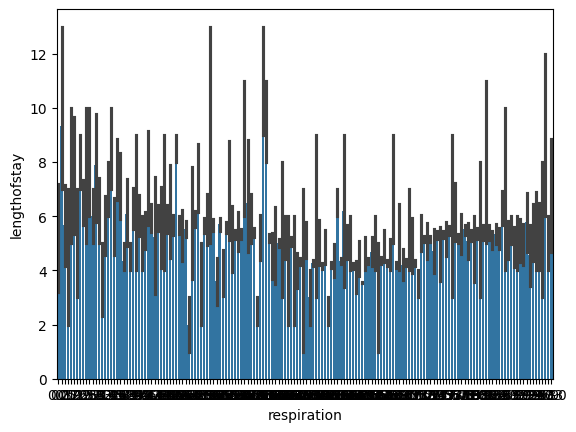

In [175]:
sns.barplot(df,x="respiration",y="lengthofstay")

Changing datatype of dialysisrenalendstage to int
changing datatype of	rcount
drop column

# Data Preprocessing

In [176]:
df["rcount"]=df["rcount"].str.replace("5+","5").astype(int)

In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   vdate                       100000 non-null  object 
 2   rcount                      100000 non-null  int64  
 3   gender                      100000 non-null  object 
 4   dialysisrenalendstage       100000 non-null  int64  
 5   asthma                      100000 non-null  int64  
 6   irondef                     100000 non-null  int64  
 7   pneum                       100000 non-null  int64  
 8   substancedependence         100000 non-null  int64  
 9   psychologicaldisordermajor  100000 non-null  int64  
 10  depress                     100000 non-null  int64  
 11  psychother                  100000 non-null  int64  
 12  fibrosisandother            100000 non-null  int64  
 13  malnutrition   

In [178]:
df=df.drop(["eid","vdate","discharged"],axis=1)

In [179]:
df

,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,...,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,facid,lengthofstay
0,0,F,0,0,0,0,0,0,0,0,...,140.361132,192.476918,12.0,1.390722,30.432418,96,6.5,4,B,3
1,5,F,0,0,0,0,0,0,0,0,...,136.731692,94.078507,8.0,0.943164,28.460516,61,6.5,1,A,7
2,1,F,0,0,0,0,0,0,0,0,...,133.058514,130.530524,12.0,1.065750,28.843812,64,6.5,2,B,3
3,0,F,0,0,0,0,0,0,0,0,...,138.994023,163.377028,12.0,0.906862,27.959007,76,6.5,1,A,1
4,0,F,0,0,0,1,0,1,0,0,...,138.634836,94.886654,11.5,1.242854,30.258927,67,5.6,2,E,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,3,M,0,0,0,0,0,0,0,0,...,132.614977,171.422555,12.0,0.650323,30.063069,80,6.5,1,B,6
99996,0,M,0,0,0,0,0,0,0,0,...,138.327320,122.342450,12.0,1.521424,28.969548,61,6.5,1,B,1
99997,1,M,0,0,1,0,0,0,0,0,...,136.695905,108.288106,12.0,1.025677,26.354919,61,6.9,1,C,4
99998,0,M,0,0,0,0,0,0,1,0,...,135.980516,111.750731,16.0,1.035400,29.193462,59,5.6,1,B,4


In [180]:
df["gender"]=df["gender"].map({"M":1,"F":0})

In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   rcount                      100000 non-null  int64  
 1   gender                      100000 non-null  int64  
 2   dialysisrenalendstage       100000 non-null  int64  
 3   asthma                      100000 non-null  int64  
 4   irondef                     100000 non-null  int64  
 5   pneum                       100000 non-null  int64  
 6   substancedependence         100000 non-null  int64  
 7   psychologicaldisordermajor  100000 non-null  int64  
 8   depress                     100000 non-null  int64  
 9   psychother                  100000 non-null  int64  
 10  fibrosisandother            100000 non-null  int64  
 11  malnutrition                100000 non-null  int64  
 12  hemo                        100000 non-null  int64  
 13  hematocrit     

In [182]:
df = pd.get_dummies(df, columns=["facid"],dtype=int)
df.head()

,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,...,bmi,pulse,respiration,secondarydiagnosisnonicd9,lengthofstay,facid_A,facid_B,facid_C,facid_D,facid_E
0,0,0,0,0,0,0,0,0,0,0,...,30.432418,96,6.5,4,3,0,1,0,0,0
1,5,0,0,0,0,0,0,0,0,0,...,28.460516,61,6.5,1,7,1,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,28.843812,64,6.5,2,3,0,1,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,27.959007,76,6.5,1,1,1,0,0,0,0
4,0,0,0,0,0,1,0,1,0,0,...,30.258927,67,5.6,2,4,0,0,0,0,1


In [183]:
df["respiration"].value_counts()

,count
respiration,
6.500000,64833
6.400000,1524
6.200000,1498
6.600000,1473
6.900000,1449
...,...
9.800000,3
1.600000,3
5.575000,2


# Feature Engineering

In [184]:
resp_bins = [0, 5.9, 7.0, 15]
resp_labels = ['Low', 'Normal', 'High']
df['respiration'] = pd.cut(df['respiration'], bins=resp_bins, labels=resp_labels)

In [185]:
df=pd.get_dummies(df,columns=["respiration"],drop_first=True,dtype=int)


In [186]:
df["bmi"]=pd.cut(df["bmi"],bins=[0,18.5,24.9,29.9,float("inf")],labels = ['Underweight', 'Normal', 'Overweight', 'Obesity'])

In [187]:
bins = [0, 6.0, 9.0, 12.0, 16.0, float('inf')]
labels = ['Severe Anemia', 'Moderate Anemia', 'Mild Anemia', 'Normal', 'High (Polycythemia)']
df['hematocrit'] = pd.cut(df['hematocrit'], bins=bins, labels=labels, right=True)

In [188]:
df['neutrophils'] = pd.cut(df['neutrophils'], bins=[0, 1.5, 7.0, float('inf')], labels=['Low', 'Normal', 'High'])

In [189]:
df['sodium'] = pd.cut(df['sodium'], bins=[0, 135, 145, float('inf')], labels=['Low', 'Normal', 'High'])

In [190]:
df['glucose'] = pd.cut(df['glucose'], bins=[0, 100, 125, float('inf')], labels=['Normal', 'Prediabetes', 'Diabetes'])

In [191]:
df['bloodureanitro'] = pd.cut(df['bloodureanitro'], bins=[0, 7, 20, float('inf')], labels=['Low', 'Normal', 'High'])

In [192]:
df['creatinine'] = pd.cut(df['creatinine'], bins=[0, 0.5, 1.2, float('inf')], labels=['Low', 'Normal', 'High'])

In [193]:
cat_cols = ['bmi','hematocrit', 'neutrophils', 'sodium', 'glucose','bloodureanitro', 'creatinine']


In [194]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

In [195]:
reporting_bins = [-1, 4, 7, float('inf')]
reporting_labels = ['Rare / Dormant Category', 'Moderate-Load Routine Case', 'Critical High-Load Condition']

In [196]:
df['secondarydiagnosisnonicd9'] = pd.cut(
df['secondarydiagnosisnonicd9'],
bins=reporting_bins,
labels=reporting_labels
)

In [197]:
df=pd.get_dummies(df,columns=["secondarydiagnosisnonicd9"],drop_first=True,dtype=int)

In [198]:
bins = [0, 1, 2, 3, 4, 5, float('inf')]
labels = [
    'Baseline / No Risk',
    'Low Risk',
    'Moderate Risk',
    'High Risk',
    'High Super-Utilizer',
    'Extreme Super-Utilizer'
]

In [199]:
df['rcount'] = pd.cut(df['rcount'], bins=bins, labels=labels)

In [200]:
df=pd.get_dummies(df,columns=["rcount"],drop_first=True,dtype=int)

In [201]:
display(df.head(3))


,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,...,bloodureanitro_High,creatinine_Normal,creatinine_High,secondarydiagnosisnonicd9_Moderate-Load Routine Case,secondarydiagnosisnonicd9_Critical High-Load Condition,rcount_Low Risk,rcount_Moderate Risk,rcount_High Risk,rcount_High Super-Utilizer,rcount_Extreme Super-Utilizer
0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [202]:
df["pulse"].value_counts()

,count
pulse,
71,3480
73,3384
72,3373
75,3371
74,3366
...,...
21,1
25,1
23,1


In [203]:
pulse_bins = [0, 60, 101, float('inf')]
pulse_labels = ['Bradycardia', 'Normal_Pulse', 'Tachycardia']
df['pulse'] = pd.cut(df['pulse'], bins=pulse_bins, labels=pulse_labels)

In [204]:
df = pd.get_dummies(df, columns=['pulse'], drop_first=True, dtype=int)

In [205]:
df.head(3)


,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,...,creatinine_High,secondarydiagnosisnonicd9_Moderate-Load Routine Case,secondarydiagnosisnonicd9_Critical High-Load Condition,rcount_Low Risk,rcount_Moderate Risk,rcount_High Risk,rcount_High Super-Utilizer,rcount_Extreme Super-Utilizer,pulse_Normal_Pulse,pulse_Tachycardia
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [206]:
#Changing all the Features into INT DType
df.astype(int)

,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,...,creatinine_High,secondarydiagnosisnonicd9_Moderate-Load Routine Case,secondarydiagnosisnonicd9_Critical High-Load Condition,rcount_Low Risk,rcount_Moderate Risk,rcount_High Risk,rcount_High Super-Utilizer,rcount_Extreme Super-Utilizer,pulse_Normal_Pulse,pulse_Tachycardia
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,0,0,1,0,1,0,0,0,...,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
99996,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
99997,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
99998,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


# MODEL SELECTION

In [207]:
x=df.drop("lengthofstay",axis=1)
y=df["lengthofstay"]

In [208]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

Linear Regression Model

In [209]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [210]:
y_predict=model.predict(x_test)

In [211]:
print(f"Mean Squared Error: {mean_squared_error(y_test, y_predict)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_predict)):.2f} days")
r2 = r2_score(y_test, y_predict)
print(f"R-squared Score: {r2:.4f}")

Mean Squared Error: 1.0776829353675268
RMSE: 1.04 days
R-squared Score: 0.8036


XGBoost Model

In [212]:
from xgboost import XGBRegressor
import numpy as np
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(x_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [213]:
y_pred_xgb = xgb_model.predict(x_test)
print(f"XGBoost MSE: {mean_squared_error(y_test, y_pred_xgb)}")
print(f"XGBoost RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.2f} days")
print(f"XGBoost R-squared Score: {r2_score(y_test, y_pred_xgb):.4f}")

XGBoost MSE: 0.9602859616279602
XGBoost RMSE: 0.98 days
XGBoost R-squared Score: 0.8250


RandomForestRegressor Model

In [214]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)


In [215]:
print(f"Random Forestt MSE: {mean_squared_error(y_test, y_pred_rf)}")
print(f"Random Forest RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f} days")
print(f"Random Forest R-squared Score: {r2_score(y_test, y_pred_rf):.4f}")

Random Forestt MSE: 1.1090951235394075
Random Forest RMSE: 1.05 days
Random Forest R-squared Score: 0.7979


GridSearchCV and XGBoost Model

In [216]:
from sklearn.model_selection import GridSearchCV
xgb_base = XGBRegressor(random_state=42)
param_grid = {'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}
grid_search = GridSearchCV(estimator=xgb_base,
                           param_grid=param_grid,
                           cv=5,
                           scoring='r2',
                           n_jobs=-1,
                           verbose=2)
grid_search.fit(x_train, y_train)
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=True, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200]},
             scoring='r2', verbose=2)

In [217]:
best_xgb_model = grid_search.best_estimator_
y_pred_tuned = best_xgb_model.predict(x_test)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)
print("--- Grid Search Cross-Validation Results ---")
print(f"Optimal Hyperparameters: {grid_search.best_params_}")
print(f"Best CV R-squared Score (Training): {grid_search.best_score_:.4f}\n")

print("--- Tuned XGBoost Model Performance (Test Data) ---")
print(f"Mean Squared Error (MSE)  : {mse_tuned:.4f}")
print(f"Root Mean Sq. Error (RMSE): {rmse_tuned:.2f} days")
print(f"R-squared Score (R2)      : {r2_tuned:.4f}")

--- Grid Search Cross-Validation Results ---
Optimal Hyperparameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
Best CV R-squared Score (Training): 0.8226

--- Tuned XGBoost Model Performance (Test Data) ---
Mean Squared Error (MSE)  : 0.9441
Root Mean Sq. Error (RMSE): 0.97 days
R-squared Score (R2)      : 0.8279


## Finalizing the Best Model & Model Building

In [218]:
import joblib as jb
import json as js

In [219]:
jb_model=jb.dump(best_xgb_model,"'xgboost_los_model.pkl'")

In [220]:
model_colms=list(x_train.columns)
with open("model_columns.json","w") as f:
  f.write(js.dumps(model_colms))

In [221]:
import shutil

# Define the destination path in Google Drive
drive_path = '/content/drive/MyDrive/'

# Copy the XGBoost model file to Google Drive
shutil.copy("'xgboost_los_model.pkl'", drive_path + "xgboost_los_model.pkl")
print("Model 'xgboost_los_model.pkl' saved to Google Drive.")

Model 'xgboost_los_model.pkl' saved to Google Drive.
